## Raw Data Importing

In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv('Reviews.csv')
df.head(3)
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


## Data Cleaning and Preprocessing

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

def lemmatize_word(word):
    """Lemmatize as noun first, then verb to catch tenses like 'tasted' -> 'taste'"""
    w = lemmatizer.lemmatize(word, pos='n')  # noun
    if w == word:  # if unchanged, try as verb
        w = lemmatizer.lemmatize(word, pos='v')
    return w

# Step 1: Remove HTML tags
df['Cleaned_Text'] = df['Text'].str.replace('<[^>]+>', ' ', regex=True)
# Step 2: Lowercase
df['Cleaned_Text'] = df['Cleaned_Text'].str.lower()
# Step 3: Remove non-alphabetic characters
df['Cleaned_Text'] = df['Cleaned_Text'].str.replace('[^a-z]+', ' ', regex=True)
# Step 4: Tokenize + lemmatize (nouns + verbs) + remove stopwords
df['Cleaned_Text'] = df['Cleaned_Text'].str.split()
df['Cleaned_Text'] = df['Cleaned_Text'].apply(lambda x:[lemmatize_word(word) for word in x if word not in stop_words])
df['Cleaned_Text'].head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alinaliu18/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/alinaliu18/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    [buy, several, vitality, can, dog, food, produ...
1    [product, arrive, label, jumbo, salt, peanut, ...
2    [confection, around, century, light, pillowy, ...
Name: Cleaned_Text, dtype: object

## Visualization (Text based)

#### Word Cloud

In [4]:
%pip install wordcloud

python(60358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
df['Target'] = df['Score'].apply(lambda x:1 if x>3 else 0)
positive_text = " ".join(df[df['Score'] > 3]['Cleaned_Text'].apply(lambda x: " ".join(x) if isinstance(x, list) else x))
negative_text = " ".join(df[df['Score'] < 3]['Cleaned_Text'].apply(lambda x: " ".join(x) if isinstance(x, list) else x))

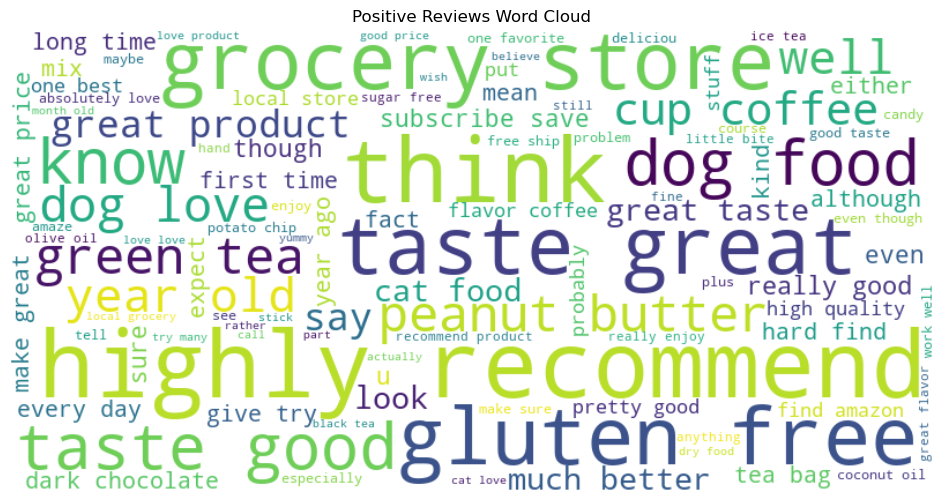

In [6]:
plt.figure(figsize = (12,6))
wc_pos = WordCloud(width = 800, height = 400, background_color = 'white', max_words = 100).generate(positive_text)
plt.imshow(wc_pos, interpolation = 'bilinear')
plt.title("Positive Reviews Word Cloud")
plt.axis('off')
plt.show()

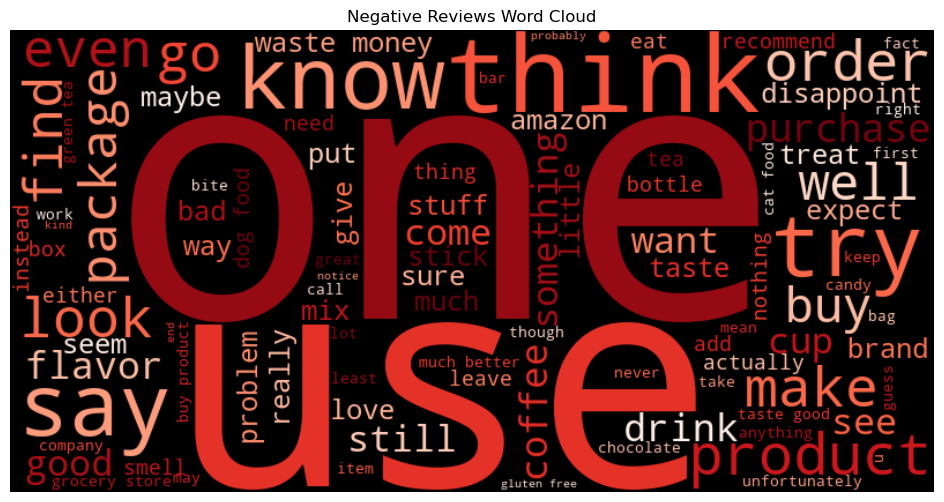

In [7]:
plt.figure(figsize = (12, 6))
wc_neg = WordCloud(width = 800, height = 400, background_color = 'black', colormap = 'Reds',max_words = 100).generate(negative_text)
plt.imshow(wc_neg, interpolation = 'bilinear')
plt.title("Negative Reviews Word Cloud")
plt.axis('off')
plt.show()

#### Bigram

/var/folders/mx/8dtymg4d6qqfs42vym0v232w0000gn/T/ipykernel_7231/1216485671.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Count', y = 'Bigram', data = common_words.head(15), palette = 'Reds_r')


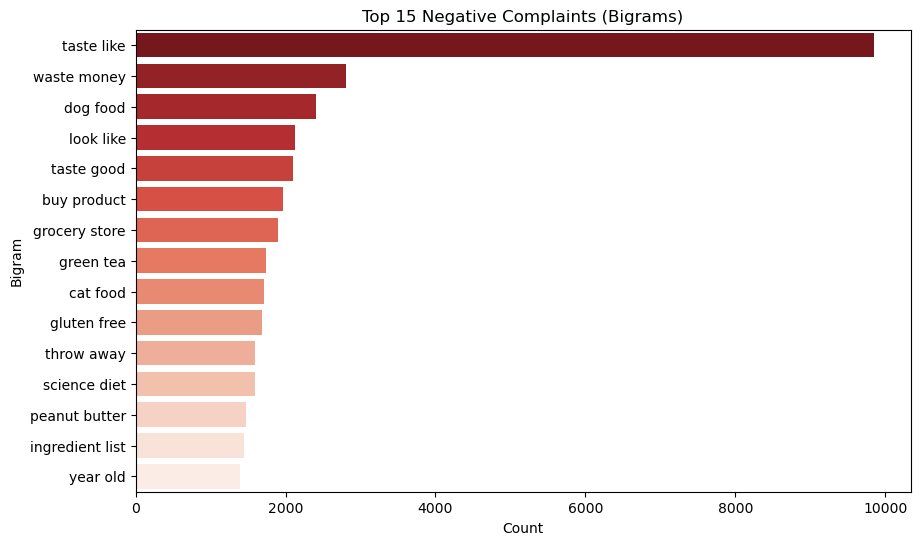

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
#look at negative_text and use ngram_range(2,2) 2 words only
vec = CountVectorizer(ngram_range = (2,2), max_features = 20, stop_words = 'english')
bag_of_words = vec.fit_transform([negative_text])
sum_words = bag_of_words.sum(axis = 0)

words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
common_words = pd.DataFrame(words_freq, columns = ['Bigram', 'Count'])

plt.figure(figsize = (10,6))
sns.barplot(x = 'Count', y = 'Bigram', data = common_words.head(15), palette = 'Reds_r')
plt.title('Top 15 Negative Complaints (Bigrams)')
plt.show()

## Feature Engineering

#### TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = df['Cleaned_Text'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
tfidf_vectorizer = TfidfVectorizer(max_features = 5000)
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
X_tfidf = tfidf_vectorizer.fit_transform(corpus).toarray()
X_tfidf.shape

(568454, 5000)

In [11]:
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
neg_indices = df[df['Target'] == 0].index

In [12]:
# Compute TF-IDF difference: negative - positive (finds words that distinguish negative reviews)
neg_tfidf_mean = X_tfidf[df['Target'] == 0].mean(axis=0)
pos_tfidf_mean = X_tfidf[df['Target'] == 1].mean(axis=0)
diff = neg_tfidf_mean - pos_tfidf_mean

tfidf_diff_df = pd.DataFrame({'Word': tfidf_feature_names, 'Score': diff})
top_neg_words = tfidf_diff_df.sort_values(by='Score', ascending=False).head(20)

/var/folders/mx/8dtymg4d6qqfs42vym0v232w0000gn/T/ipykernel_7231/449425579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Score', y = 'Word', data = top_neg_words, palette = 'magma')


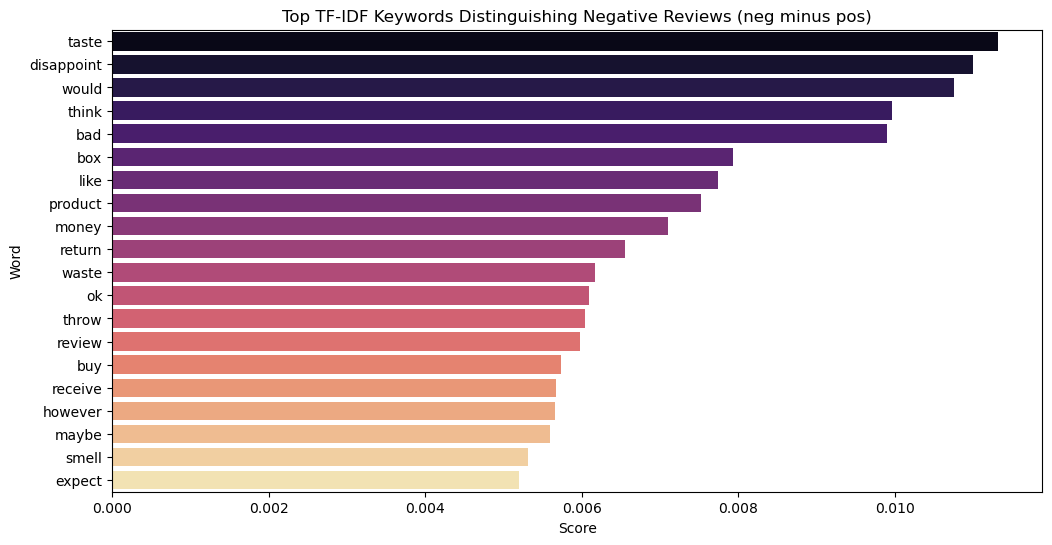

In [13]:
plt.figure(figsize = (12, 6))
sns.barplot(x = 'Score', y = 'Word', data = top_neg_words, palette = 'magma')
plt.title('Top TF-IDF Keywords Distinguishing Negative Reviews (neg minus pos)')
plt.show()

#### WordToVector Embedding

In [14]:
sentences = df['Cleaned_Text'].to_list()

In [15]:
%pip install gensim

python(64775) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [16]:
from gensim.models import Word2Vec
w2vmodel = Word2Vec(sentences, vector_size = 100, window = 5, min_count = 1)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [17]:
def get_doc_vector(doc_tokens, model):
    valid_tokens = [word for word in doc_tokens if word in model.wv.key_to_index]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    x = np.mean([model.wv[word] for word in valid_tokens],axis = 0) #average of the valid tokens
    return x

In [18]:
X = np.array([get_doc_vector(tokens, w2vmodel) for tokens in sentences])

In [19]:
X.shape

(568454, 100)

## Visualization (Vector based)

In [20]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

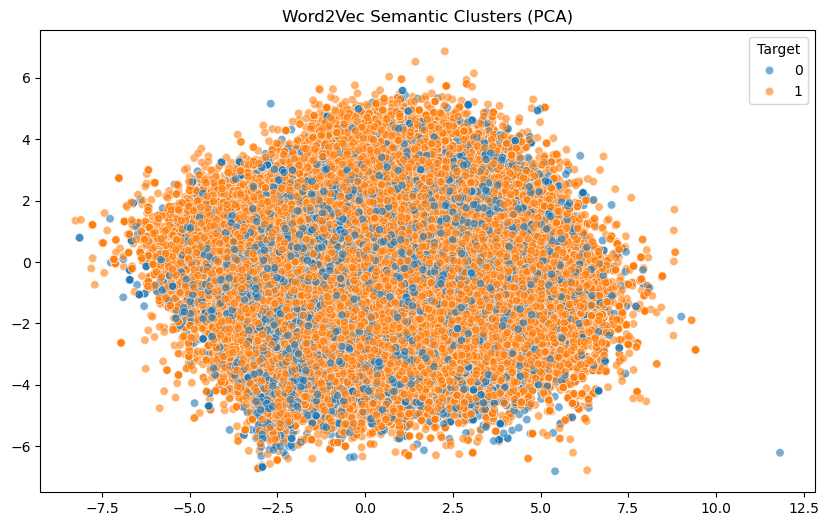

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = X_pca[:,0], y = X_pca[:,1], hue = df['Target'], alpha = 0.6)
plt.title("Word2Vec Semantic Clusters (PCA)")
plt.show()

The PCA plot demonstrates that Word2Vec successfully captured semantic relationships, grouping positive and negative reviews into distinguishable clusters in the vector space. A simple TF-IDF approach often fails to create such clear semantic separation because it ignores the context between words.

## Model Building

### Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
y = df['Target']

#### Word2Vec

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

In [25]:
print("Training Random Forest: ")
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42, n_jobs = -1)
rf_model.fit(X_train, y_train)

Training Random Forest: 


python(64926) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [26]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

In [27]:
print(f"RF AUC built on Word2Vec: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

RF AUC built on Word2Vec: 0.9004
              precision    recall  f1-score   support

           0       0.87      0.35      0.49     31169
           1       0.84      0.98      0.91    110945

    accuracy                           0.84    142114
   macro avg       0.85      0.67      0.70    142114
weighted avg       0.85      0.84      0.82    142114



### Logistic Regression

#### TF-IDF

In [1]:
from sklearn.linear_model import LogisticRegression
import seaborn as sns
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.25, random_state=42, stratify=y)

lr_tfidf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train_tfidf)
lr_tfidf_prob = lr_tfidf.predict_proba(X_test_tfidf)[:,1]

print(f"LR AUC built on TF-IDF: {roc_auc_score(y_test_tfidf, lr_tfidf_prob):.4f}")
print(classification_report(y_test_tfidf, lr_tfidf.predict(X_test_tfidf)))

NameError: name 'train_test_split' is not defined

#### Word2Vec

In [ ]:
print("Training Logistic Regression for comparison...")
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train, y_train)

In [ ]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

print(f"LR AUC built on Word2Vec: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

## Model Selection (Fine-Tuning and CV)

### Cross Validation (Hyperparameter Tuning)

#### Random Forest (max_depth)

In [ ]:
depths = [5, 10, 15, 20, 30, None]
train_scores = []
test_scores = []
print("Tuning max_depth...")

In [ ]:
for d in depths:
    n_jobs = -1
    rf = RandomForestClassifier(n_estimators = 50, max_depth = d, random_state = 42, n_jobs = -1)
    rf.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:,1])
    test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

    train_scores.append(train_auc)
    test_scores.append(test_auc)
    print(f"Depth: {d} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, label = 'Train AUC (Low Bias)', marker = 'o', color = 'lightblue')
plt.plot(depths, test_scores, label = 'Test AUC (Low Variance)', marker = 'o', color = 'forestgreen')
plt.title("Bias-Variance Tradeoff: Optimization of Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(True)
plt.show()

#### Logistic Regression (Word2Vec)

In [ ]:
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_scores_lr = []
test_scores_lr = []
print("Tuning Logistic Regression C parameter:")
for c in C_values:
    lr = LogisticRegression(C = c, max_iter = 1000, random_state = 42)
    lr.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

    train_scores_lr.append(train_auc)
    test_scores_lr.append(test_auc)
    print(f"C:{c} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")
    

In [ ]:
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
train_scores_lr_tfidf = []
test_scores_lr_tfidf = []

print("Tuning Logistic Regression C parameter (TF-IDF):")
for c in C_values:
    lr = LogisticRegression(C = c, max_iter = 1000, random_state = 42)
    lr.fit(X_train_tfidf, y_train_tfidf)

    train_auc = roc_auc_score(y_train_tfidf, lr.predict_proba(X_train_tfidf)[:, 1])
    test_auc = roc_auc_score(y_test_tfidf, lr.predict_proba(X_test_tfidf)[:, 1])

    train_scores_lr_tfidf.append(train_auc)
    test_scores_lr_tfidf.append(test_auc)
    print(f"C:{c} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")

#### Logistic Regression (TF-IDF)

The optimal C parameter is 0.1.

## Model Comparison & Evaluation

### Retraining & ROC AUC Graph

#### Random Forest

In [ ]:
print("Training Final Model (Max Depth = 20)...")
rf_final = RandomForestClassifier(n_estimators = 100, max_depth = 20, random_state = 42, n_jobs = -1)
rf_final.fit(X_train, y_train)

In [ ]:
final_pred = rf_final.predict(X_test)
final_prob = rf_final.predict_proba(X_test)[:,1]

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, final_pred))
print(f"AUC Score:{roc_auc_score(y_test, final_prob):.4f}")

#### Logistic Regression

In [ ]:
print("Training Logistic Regression with C = 0.1")
lr_final = LogisticRegression(C = 0.1, max_iter = 1000, random_state = 42)
lr_final.fit(X_train, y_train)                             

In [ ]:
final_pred_lr = lr_final.predict(X_test)
final_prob_lr = lr_final.predict_proba(X_test)[:,1]

In [ ]:
print("\nClassification report:")
print(classification_report(y_test, final_pred_lr))
print(f"AUC score :{roc_auc_score(y_test, final_prob_lr):.4f}")

In [ ]:
print("Training Final Logistic Regression Model (TF-IDF)...")
# Using C=0.1 as a reasonable default, adjust based on tuning results
lr_final_tfidf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
lr_final_tfidf.fit(X_train_tfidf, y_train_tfidf)

final_pred_lr_tfidf = lr_final_tfidf.predict(X_test_tfidf)
final_prob_lr_tfidf = lr_final_tfidf.predict_proba(X_test_tfidf)[:,1]

print("\nClassification Report (LR TF-IDF):")
print(classification_report(y_test_tfidf, final_pred_lr_tfidf))
print(f"AUC Score: {roc_auc_score(y_test_tfidf, final_prob_lr_tfidf):.4f}")

#### Logistic Regression (TF-IDF) - Final Model

#### Comparison

In [ ]:
#RF
fpr, tpr, thresholds_rf = roc_curve(y_test, final_prob)
roc_auc = auc(fpr, tpr)
#LR
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, final_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
    
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot(fpr_lr, tpr_lr, color = 'darkblue', lw = 2, label = f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.03])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()

Overall, Random Forest is more effective in classifying the sentiment in the Amazon Food Review dataset then Logistic Regression due to higher ROC/AUC score. In terms of the classification report, Random Forest also has higher precision, recall, f1 score compared to Logistic Regression. However, time complexity wise, Logistic Regression runs for a significantly less amount of time than Random Forest.

### Feature Importance

#### TF-IDF

In [ ]:
## Using LR on TF-IDF (coefficients = directional)
coefs = lr_tfidf.coef_[0]
top_pos = coefs.argsort()[-10:][::-1]
top_neg = coefs.argsort()[:10]
print("LR Top 10 positive-driving words:")
for i in top_pos:
    print(f"  {tfidf_feature_names[i]}: {coefs[i]:.4f}")
print("\nLR Top 10 negative-driving words:")
for i in top_neg:
    print(f"  {tfidf_feature_names[i]}: {coefs[i]:.4f}")

#### Word2Vec

In [ ]:
w2v_importances = rf_final.feature_importances_
w2v_feature_names = [f"Dim_{i}" for i in range(X_train.shape[1])]
feature_imp_df = pd.DataFrame({'Feature': w2v_feature_names, 'Importance': w2v_importances})

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x = 'Importance', y = 'Feature', data = feature_imp_df.sort_values(by = 'Importance', ascending = False).head(15), palette = 'viridis')
plt.title("Feature Importance (Word2Vec Semantic Dimensions)")
plt.show()

It turns out that Dim_60, Dim_41, Dim_28 are top three important features in Words2Vec semantics for classifying the good/bad food reviews.


## Restore Model

In [ ]:
import joblib
joblib.dump(rf_final, 'amazon_sentiment_final.pkl')
joblib.dump(lr_final, 'amazon_sentiment_final_lr.pkl')
joblib.dump(lr_final_tfidf, 'amazon_sentiment_final_lr_tfidf.pkl')
